In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["PATH"] += os.pathsep + '/home/icb/mostafa.shahhosseini/miniconda3/envs/lupien/bin'
import pybedtools
import numpy as np
import pandas as pd
from tqdm import tqdm
import chromATAC as ca
from chromATAC.integrated import IntData
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
from concurrent.futures import ProcessPoolExecutor
from chromATAC.al import mann_whitney_test, wilcoxon_test
from scipy.stats import ks_2samp

In [3]:
parent_dir = '/home/icb/mostafa.shahhosseini/data/lupien/'

In [4]:
os.chdir(parent_dir)

In [5]:
def compare_category_pairs(df, 
                           categories, 
                           group_col='Group', 
                           target_col='peak_count',
                           test='mann_whitney',
                           nz=False
                           ):
    all_categories = df[group_col].unique()
    other_categories = [cat for cat in all_categories if cat not in categories]
    pvalues = {}
    for cat1 in categories:
        pvalues[cat1] = []
        for cat2 in other_categories:
            s1 = df[df[group_col]==cat1].loc[:, target_col].values
            s2 = df[df[group_col]==cat2].loc[:, target_col].values
            if nz:
                s1 = s1[s1!=0]
                s2 = s2[s2!=0]
            if test=='mann_whitney':
                p_value = mann_whitney_test(s1, s2)
            if test=='ks':
                _, p_value = ks_2samp(s1, s2)
            pvalues[cat1].append(p_value)
    pval_df = pd.DataFrame(pvalues)
    pval_df.index=other_categories
    return pval_df

In [6]:
def compare_groupings(df, nz=False, test='mann_whitney'):
    groups = [i for i in df.columns if i.startswith('group')]
    pval_dfs = {}
    for g in tqdm(groups):
        n = int(g.replace('groups', ''))
        pval_dfs[g] = []
        for i in range(1, n+1):
            group_ct = df['Group'][df[g]==i].unique()
            pval = compare_category_pairs(df, [i], group_col=g, nz=nz, test=test)
            pval_dfs[g].append(pval)
        pval_dfs[g] = pd.concat(pval_dfs[g], axis=1).sort_index()
    return pval_dfs

--------

In [7]:
grouping_tables = []
for f in os.listdir('./new-TCGA/groupings/'):
    if f.endswith('.csv'):
        with open(os.path.join('./new-TCGA/groupings/', f)) as t:
            d = pd.read_csv(t)
            grouping_tables += [d]

In [8]:
groups = pd.concat([i.iloc[:, 4:] for i in grouping_tables], axis=1)
groups = pd.concat([d.iloc[:, [2, 3]], groups], axis=1)

In [9]:
def load_te(path):
    df = pd.read_csv(path, sep='\t', index_col=0)
    df = df[df['chrom'].apply(lambda x: x in ca.info.CHROMOSOMES['names'])]
    # df['sample'] = df['sample'].apply(lambda x: x.split('_peak')[0])
    return df

In [21]:
samples = groups['SampleName'].unique()

In [100]:
df = df.merge(groups.set_index('SampleName'), left_on='sample', right_on='SampleName')

In [219]:
comp_df = compare_groupings(peak_sum)

100%|██████████| 25/25 [00:07<00:00,  3.34it/s]


In [264]:
TE = 'LINE_L1_L1MA1.tsv'

In [14]:
tes = os.listdir('./new-TCGA/TE.intersection/')

In [11]:
_tes = os.listdir('./new-TCGA/TE.intersection/te_agg/')

In [16]:
__tes = set(tes)-set(_tes)

In [23]:
tes_df = {}
for TE in tqdm(__tes):
    if TE.endswith('.tsv'):
        df = load_te(f'./new-TCGA/TE.intersection/{TE}')
        tes_df[TE] = pd.DataFrame({ 'sample':[], 'chrom':[], 'peak_count':[], 'TE':[]})
        grouped_data = []
        for s in samples:
            temp_df = df[df['sample'] == s].groupby(['sample', 'chrom']).sum().iloc[:, [2]].sort_index()
            grouped_data.append(temp_df)
        # Concatenate the results|
        peak_sum = pd.concat(grouped_data).reset_index()
        peak_sum['TE'] = TE.replace('.tsv', '')
        tes_df[TE] = pd.concat([tes_df[TE], peak_sum])
        tes_df[TE].to_csv(f'./new-TCGA/TE.intersection/te_agg/{TE}', sep='\t')

100%|██████████| 273/273 [3:30:34<00:00, 46.28s/it]    


In [215]:
peak_sum['sample'] = peak_sum['sample'].apply(lambda x: x.split('_pe', 1)[0])

In [216]:
peak_sum = peak_sum.merge(groups, left_on='sample', right_on='SampleName').drop(columns='SampleName')

In [259]:
peak_sum

,sample,chrom,peak_count,Group,groups2,groups3,groups4,groups5,groups6,groups7,...,groups17,groups18,groups19,groups20,groups21,groups22,groups23,groups24,groups25,groups26
0,552d580e-6346-4127-8859-6d1714ce33e1,chr1,4.0,COAD,1,1,1,1,1,1,...,15,16,16,16,17,17,18,18,19,19
1,552d580e-6346-4127-8859-6d1714ce33e1,chr10,0.0,COAD,1,1,1,1,1,1,...,15,16,16,16,17,17,18,18,19,19
2,552d580e-6346-4127-8859-6d1714ce33e1,chr11,1.0,COAD,1,1,1,1,1,1,...,15,16,16,16,17,17,18,18,19,19
3,552d580e-6346-4127-8859-6d1714ce33e1,chr12,2.0,COAD,1,1,1,1,1,1,...,15,16,16,16,17,17,18,18,19,19
4,552d580e-6346-4127-8859-6d1714ce33e1,chr13,0.0,COAD,1,1,1,1,1,1,...,15,16,16,16,17,17,18,18,19,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9835,25408a36-3d9e-45c6-b686-dda37ff4aff5,chr7,0.0,LUSC,2,3,3,3,4,5,...,14,15,15,15,16,16,17,17,18,18
9836,25408a36-3d9e-45c6-b686-dda37ff4aff5,chr8,0.0,LUSC,2,3,3,3,4,5,...,14,15,15,15,16,16,17,17,18,18
9837,25408a36-3d9e-45c6-b686-dda37ff4aff5,chr9,0.0,LUSC,2,3,3,3,4,5,...,14,15,15,15,16,16,17,17,18,18
9838,25408a36-3d9e-45c6-b686-dda37ff4aff5,chrX,0.0,LUSC,2,3,3,3,4,5,...,14,15,15,15,16,16,17,17,18,18


In [227]:
def subplots(d, figsize=(6, 90), log_scale=True):
    fig, axs = plt.subplots(len(d), 1, figsize=figsize, sharex=True)
    for i, (k, v) in enumerate(d.items()):
        ax = axs.flatten()[i]
        sns.kdeplot(d[k], log_scale=log_scale, ax=axs.flatten()[i], legend=False)
        ax.axvline(x=0.05, color='red', linestyle='--')
        ax.set_title(k)

In [255]:
def global_plot(comp_df):
    melted_dfs = []
    for i, d in comp_df.items():
        df_melted = d.melt(var_name='Variable', value_name='Value')
        df_melted['Group'] = i
        melted_dfs.append(df_melted)
    
    # Combine all melted DataFrames
    combined_melted_df = pd.concat(melted_dfs).dropna()
    plt.figure(figsize=(8, 25))
    sns.stripplot(y='Group', x='Value', hue='Variable', data=combined_melted_df, orient='h')
    plt.axvline(x=0.05, color='grey', linestyle='--')
    plt.show()

In [257]:
ch1_ps

,sample,chrom,peak_count,Group,groups2,groups3,groups4,groups5,groups6,groups7,...,groups17,groups18,groups19,groups20,groups21,groups22,groups23,groups24,groups25,groups26
0,552d580e-6346-4127-8859-6d1714ce33e1,chr1,4.0,COAD,1,1,1,1,1,1,...,15,16,16,16,17,17,18,18,19,19
24,3e3c596d-f89c-40d2-84d8-db5f58d49860,chr1,1.0,PRAD,2,3,3,3,4,4,...,5,5,5,5,5,5,5,5,5,5
48,834f77a5-44b2-447f-b1bc-47f7f449b616,chr1,2.0,BRCA,2,3,3,3,4,4,...,9,9,9,9,9,9,9,9,10,10
72,9123cfa4-442c-4dc8-a0ff-5837fd931058,chr1,3.0,GBM,2,3,3,3,4,4,...,9,9,9,9,9,9,9,9,10,10
96,873191f5-f417-4e94-a62a-c49503a8f6be,chr1,1.0,THCA,2,2,2,2,2,2,...,17,18,19,20,21,22,23,23,24,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9720,e40a911f-8b1d-4cb4-940c-bc8bbee1b902,chr1,7.0,SKCM,2,2,2,2,2,2,...,3,3,3,3,3,3,3,3,3,26
9744,b0dde559-618f-43ce-9ccf-66c744f8e831,chr1,4.0,BRCA,2,2,2,2,2,2,...,3,3,3,3,3,3,3,3,3,3
9768,a5017f04-4c69-46c6-9b18-8be399a6b85f,chr1,6.0,BRCA,1,1,1,1,1,1,...,6,6,6,6,6,6,6,6,6,6
9792,6a8e5eba-93c5-4d3f-befd-5dbd56773b93,chr1,7.0,LUAD,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2


In [250]:
ch1_ps = peak_sum[peak_sum['chrom']=='chr1']

In [252]:
ch1_comp_df = compare_groupings(ch1_ps)

100%|██████████| 25/25 [00:06<00:00,  3.92it/s]


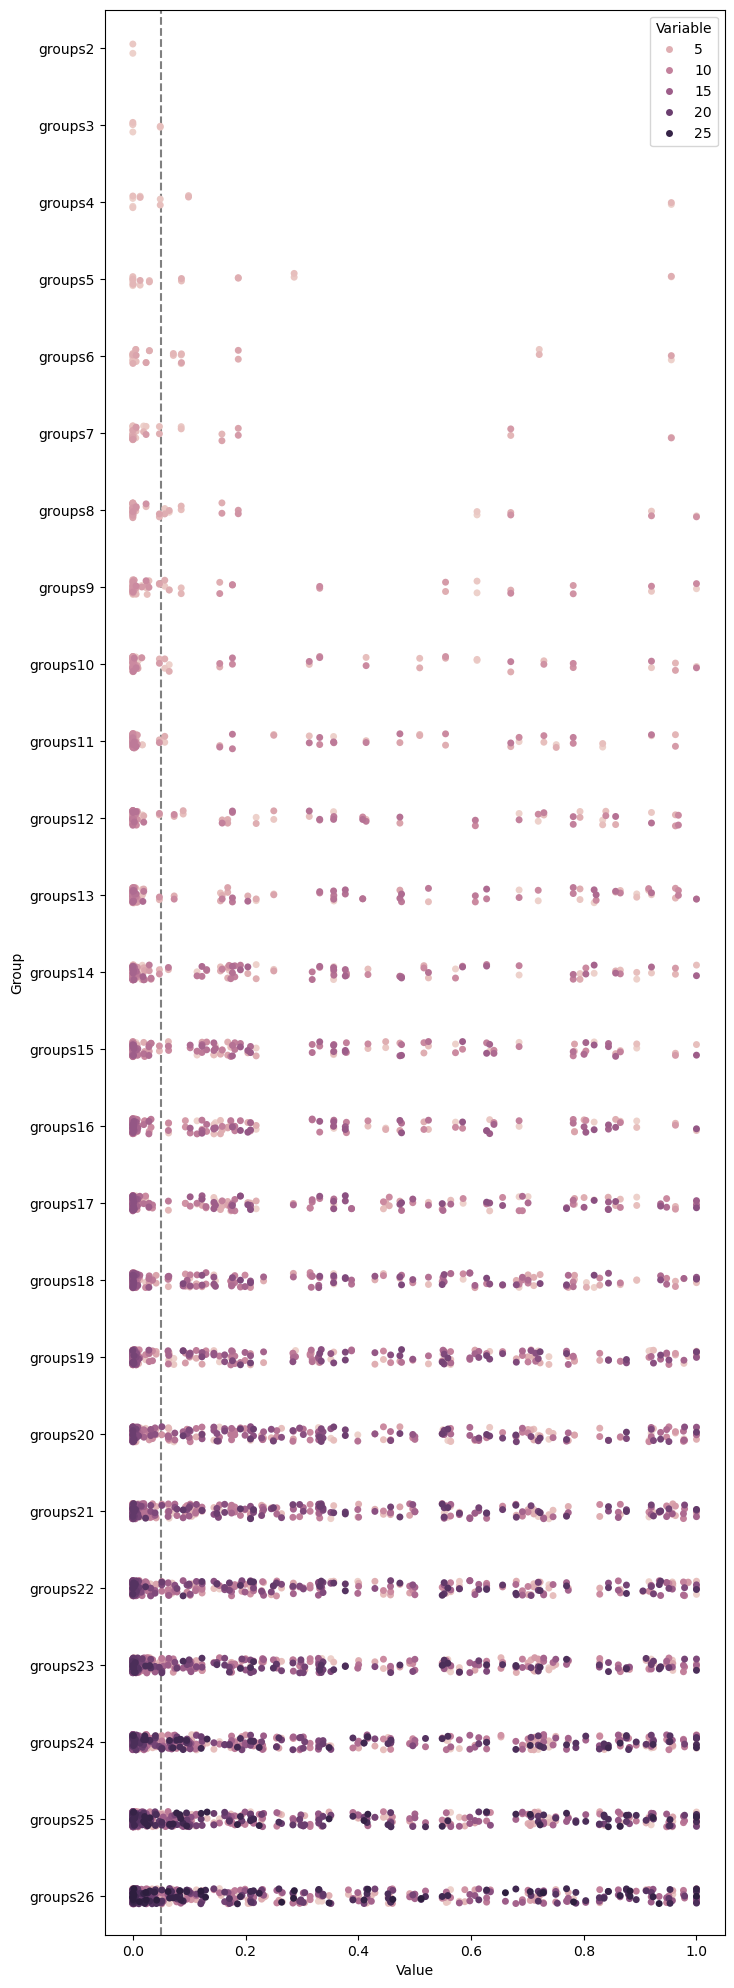

In [258]:
global_plot(ch1_comp_df)

In [452]:
def stacked_kde(d):
    for i, g in d.items():
        sns.kdeplot(g.values.flatten(), fill=True, alpha=0.1)

In [455]:
def stacked_box(d):
    for i, g in d.items():
        sns.boxplot(g.values.flatten())